# Hindi Speech Emotion Recognition
## Parallel CNN + Transformer Encoder

Adapted from [Zenkov (2020)](https://github.com/IliaZenkov/transformer-cnn-emotion-recognition)  
**Dataset:** `my Dataset/` — 8 actors × 5 sessions × 8 emotions × 10 sentences = **3,200 samples**

```
my Dataset/
  {actor 1-8}/
    {session1-5}/
      {emotion}/
        {actor}.{session}.{emotion}-{sentence}.wav
```

**Split:** Random 70 / 15 / 15 train / val / test  
**Features:** Mel spectrogram (128 bands) + AWGN augmentation


## 1. Imports & Config

In [18]:
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 40.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 62.4 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print('PyTorch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PyTorch: 2.6.0+cu124
Device: cuda


In [4]:
# ── Dataset path ──────────────────────────────────────────────────────────
# Update this to wherever 'my Dataset' lives on your machine
DATASET_PATH = r'my_Dataset_mix'   # <── CHANGE ME

# ── Audio config ──────────────────────────────────────────────────────────
SAMPLE_RATE  = 22050
DURATION     = 3        # seconds — clips are trimmed/padded to this length
N_MELS       = 128
HOP_LENGTH   = 512
N_FFT        = 2048

# ── Training config ───────────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-4
SEED         = 42

# ── Emotion classes (alphabetical order used throughout) ──────────────────
EMOTIONS    = ['anger', 'disgust', 'fear', 'happy',
               'neutral', 'sad', 'sarcastic', 'surprise']
NUM_CLASSES = len(EMOTIONS)
E2I         = {e: i for i, e in enumerate(EMOTIONS)}   # emotion → int label

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config loaded. Classes:', EMOTIONS)

Config loaded. Classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']


## 2. Dataset Exploration

In [5]:
# Walk the nested structure and build a metadata DataFrame
records = []
for actor in sorted(os.listdir(DATASET_PATH)):
    actor_dir = os.path.join(DATASET_PATH, actor)
    if not os.path.isdir(actor_dir): continue
    for session in sorted(os.listdir(actor_dir)):
        session_dir = os.path.join(actor_dir, session)
        if not os.path.isdir(session_dir): continue
        for emotion in EMOTIONS:
            emo_dir = os.path.join(session_dir, emotion)
            if not os.path.isdir(emo_dir): continue
            for wav in sorted(glob.glob(os.path.join(emo_dir, '*.wav'))):
                records.append({
                    'filepath': wav,
                    'actor':    actor,
                    'session':  session,
                    'emotion':  emotion,
                    'label':    E2I[emotion]
                })

meta = pd.DataFrame(records)
print(f'Total files found: {len(meta)}')
print(meta.head(10))

Total files found: 25600
                                           filepath actor   session emotion  \
0  my_Dataset_mix\1\session1\anger\1.1.anger-01.wav     1  session1   anger   
1  my_Dataset_mix\1\session1\anger\1.1.anger-02.wav     1  session1   anger   
2  my_Dataset_mix\1\session1\anger\1.1.anger-03.wav     1  session1   anger   
3  my_Dataset_mix\1\session1\anger\1.1.anger-04.wav     1  session1   anger   
4  my_Dataset_mix\1\session1\anger\1.1.anger-05.wav     1  session1   anger   
5  my_Dataset_mix\1\session1\anger\1.1.anger-06.wav     1  session1   anger   
6  my_Dataset_mix\1\session1\anger\1.1.anger-07.wav     1  session1   anger   
7  my_Dataset_mix\1\session1\anger\1.1.anger-08.wav     1  session1   anger   
8  my_Dataset_mix\1\session1\anger\1.1.anger-09.wav     1  session1   anger   
9  my_Dataset_mix\1\session1\anger\1.1.anger-10.wav     1  session1   anger   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  
5      0  
6      0  
7      0  
8     

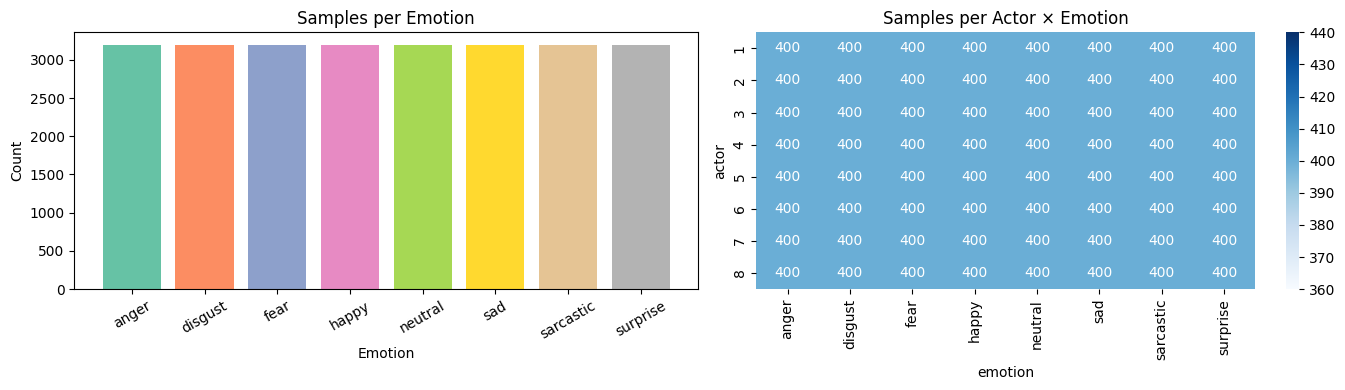

In [6]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = meta['emotion'].value_counts().reindex(EMOTIONS)
axes[0].bar(EMOTIONS, counts.values, color=plt.cm.Set2.colors)
axes[0].set_title('Samples per Emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

pivot = meta.groupby(['actor', 'emotion']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='d', cmap='Blues')
axes[1].set_title('Samples per Actor × Emotion')

plt.tight_layout()
plt.show()

In [7]:
# Listen to a sample from each emotion
print('Sample clips (one per emotion):')
for emotion in EMOTIONS:
    sample_path = meta[meta['emotion'] == emotion]['filepath'].iloc[0]
    print(f'\n{emotion.upper()}: {os.path.basename(sample_path)}')
    display(Audio(sample_path))

Sample clips (one per emotion):

ANGER: 1.1.anger-01.wav



DISGUST: 1.1.disgust-01.wav



FEAR: 1.1.fear-01.wav



HAPPY: 1.1.happy-01.wav



NEUTRAL: 1.1.neutral-01.wav



SAD: 1.1.sad-01.wav



SARCASTIC: 1.1.sarcastic-01.wav



SURPRISE: 1.1.surprise-01.wav


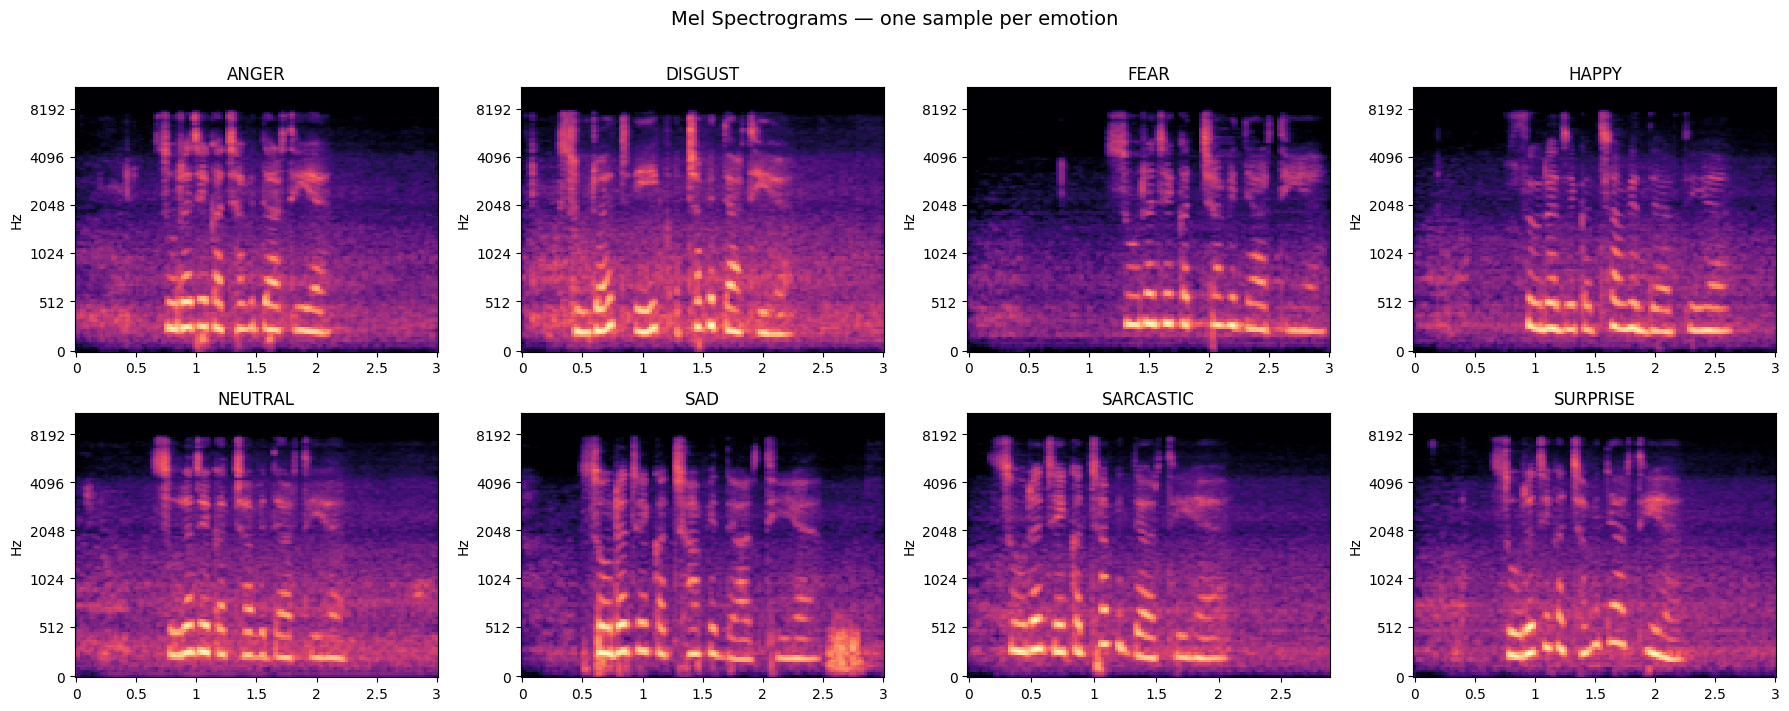

In [8]:
# Visualise mel spectrograms for each emotion
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS):
    fp = meta[meta['emotion'] == emotion]['filepath'].iloc[0]
    y, sr = librosa.load(fp, sr=SAMPLE_RATE, duration=DURATION)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=axes[i],
                              cmap='magma')
    axes[i].set_title(emotion.upper(), fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Mel Spectrograms — one sample per emotion', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Feature Extraction

In [9]:
def extract_mel(filepath, sr=SAMPLE_RATE, duration=DURATION):
    """Load .wav and return a fixed-size mel spectrogram (N_MELS × T)."""
    y, _ = librosa.load(filepath, sr=sr, duration=duration)
    target_len = sr * duration
    # Pad short clips; trim long ones
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db  # (N_MELS, T)


def awgn_augment(mel, noise_factor=0.005):
    """Additive White Gaussian Noise — same technique as original repo."""
    noise = np.random.randn(*mel.shape) * noise_factor * mel.std()
    return mel + noise

In [10]:
# Extract features for every file + one AWGN-augmented copy
features, labels = [], []

for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Extracting features'):
    try:
        mel = extract_mel(row['filepath'])
        features.append(mel)
        labels.append(row['label'])
        # Augmented copy
        features.append(awgn_augment(mel))
        labels.append(row['label'])
    except Exception as e:
        print(f'Error: {row["filepath"]} — {e}')

X = np.array(features)   # (N*2, N_MELS, T)
y = np.array(labels)      # (N*2,)
print(f'Feature array: {X.shape}  Labels: {y.shape}')

Extracting features: 100%|██████████| 25600/25600 [10:47<00:00, 39.54it/s]


Feature array: (51200, 128, 130)  Labels: (51200,)


In [11]:
# StandardScaler — flatten → scale → reshape
N, H, W = X.shape
scaler  = StandardScaler()
X_flat  = scaler.fit_transform(X.reshape(N, -1))
X       = X_flat.reshape(N, H, W)

# Add channel dimension for CNN input: (N, 1, H, W)
X = X[:, np.newaxis, :, :]
print(f'Scaled array shape: {X.shape}')

Scaled array shape: (51200, 1, 128, 130)


## 4. Train / Val / Test Split  (70 / 15 / 15)

In [12]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

# Verify class balance in each split
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(yy, return_counts=True)
    print(f'{name}: { {EMOTIONS[u]: c for u, c in zip(unique, counts)} }')

Train: 35840  Val: 7680  Test: 7680
Train: {'anger': np.int64(4480), 'disgust': np.int64(4480), 'fear': np.int64(4480), 'happy': np.int64(4480), 'neutral': np.int64(4480), 'sad': np.int64(4480), 'sarcastic': np.int64(4480), 'surprise': np.int64(4480)}
Val: {'anger': np.int64(960), 'disgust': np.int64(960), 'fear': np.int64(960), 'happy': np.int64(960), 'neutral': np.int64(960), 'sad': np.int64(960), 'sarcastic': np.int64(960), 'surprise': np.int64(960)}
Test: {'anger': np.int64(960), 'disgust': np.int64(960), 'fear': np.int64(960), 'happy': np.int64(960), 'neutral': np.int64(960), 'sad': np.int64(960), 'sarcastic': np.int64(960), 'surprise': np.int64(960)}


## 5. Dataset & DataLoader

In [13]:
class SERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SERDataset(X_train, y_train),
                           batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(SERDataset(X_val,   y_val),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(SERDataset(X_test,  y_test),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('DataLoaders ready.')
sample_x, sample_y = next(iter(train_loader))
print(f'Batch shape: {sample_x.shape}  Labels: {sample_y[:8].tolist()}')

DataLoaders ready.
Batch shape: torch.Size([32, 1, 128, 130])  Labels: [1, 6, 3, 1, 1, 0, 6, 0]


## 6. Model Architecture

Exactly as in Zenkov (2020): **two parallel CNN branches** (3×3 and 5×5 kernels)  
feeding spatial features, **plus a Transformer Encoder branch** capturing temporal patterns —  
all three concatenated into a shared classifier head.

```
Input (B, 1, 128, T)
      │              │               │
  CNN Branch 1   CNN Branch 2   Transformer
  (3×3 kernels)  (5×5 kernels)  Encoder
      │              │               │
      └──────────────┴───────────────┘
                  concat
              Fully Connected
              8-class output
```


In [14]:
class ParallelCNNTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, n_mels=N_MELS):
        super().__init__()
        self._num_classes = num_classes

        # ── CNN Branch 1  (3×3) ───────────────────────────────────────────
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
        )

        # ── CNN Branch 2  (5×5) ───────────────────────────────────────────
        self.cnn2 = nn.Sequential(
            nn.Conv2d(1,   64,  5, padding=2), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(64,  128, 5, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(128, 256, 5, padding=2), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
        )

        # ── Transformer Branch ────────────────────────────────────────────
        self.t_proj = nn.Linear(n_mels, 128)
        enc_layer   = nn.TransformerEncoderLayer(
            d_model=128, nhead=4, dim_feedforward=256,
            dropout=0.2, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)

        # Classifier built lazily after first forward pass (size depends on T)
        self.classifier = None

    def _build_classifier(self, flat_size):
        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, self._num_classes)
        ).to(next(self.parameters()).device)

    def forward(self, x):
        # CNN branches
        c1 = self.cnn1(x).flatten(1)
        c2 = self.cnn2(x).flatten(1)

        # Transformer: (B,1,H,T) → (B,T,H) → project → encode → pool
        xt = x.squeeze(1).permute(0, 2, 1)   # (B, T, N_MELS)
        xt = self.t_proj(xt)                  # (B, T, 128)
        xt = self.transformer(xt).mean(dim=1) # (B, 128)

        combined = torch.cat([c1, c2, xt], dim=1)

        if self.classifier is None:
            self._build_classifier(combined.size(1))

        return self.classifier(combined)


model = ParallelCNNTransformer().to(device)

# Warm-up pass to materialise lazy classifier
with torch.no_grad():
    _ = model(sample_x.to(device))

total_params = sum(p.numel() for p in model.parameters())
print(f'Model built — {total_params:,} parameters')
print(model)

Model built — 68,988,808 parameters
ParallelCNNTransformer(
  (cnn1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.2, inplace=False)


## 7. Training

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            if train: optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct    += (out.argmax(1) == y_b).sum().item()
            total      += len(y_b)
    return total_loss / total, correct / total

print('Training functions ready.')

Training functions ready.


In [16]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
CHECKPOINT   = 'best_model.pt'

epoch_bar = tqdm(range(1, EPOCHS + 1), desc='Training')
for epoch in epoch_bar:
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step(va_acc)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CHECKPOINT)

    epoch_bar.set_postfix({
        'tr_acc': f'{tr_acc:.3f}',
        'va_acc': f'{va_acc:.3f}',
        'best':   f'{best_val_acc:.3f}'
    })

print(f'\nTraining complete. Best validation accuracy: {best_val_acc:.4f}')

Training: 100%|██████████| 100/100 [4:08:31<00:00, 149.11s/it, tr_acc=1.000, va_acc=0.989, best=0.989] 


Training complete. Best validation accuracy: 0.9892


## 8. Training Curves

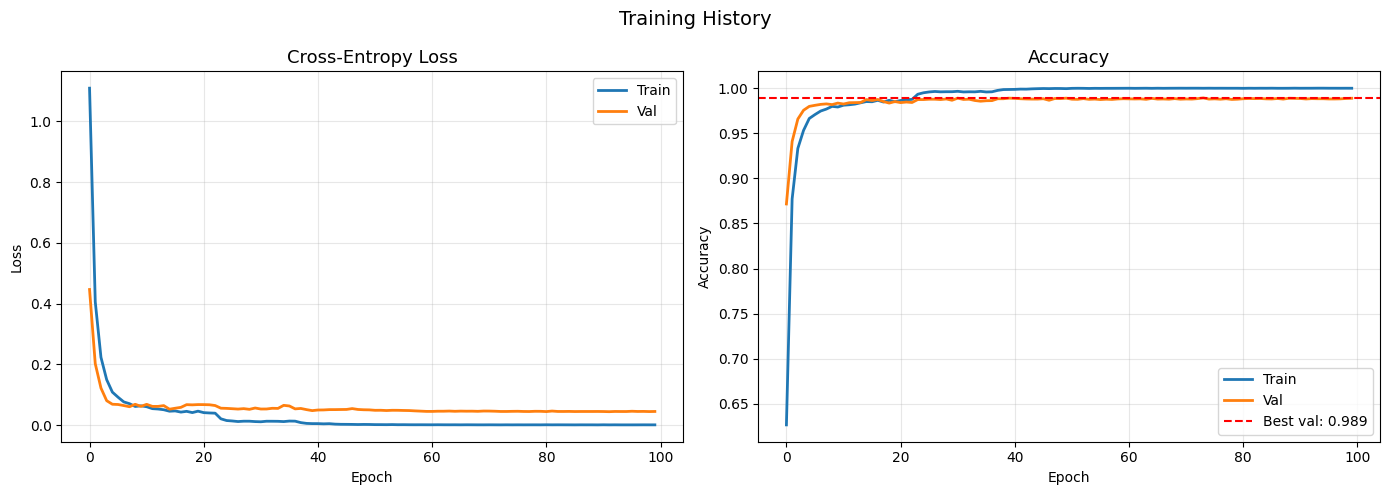

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Cross-Entropy Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=2)
axes[1].axhline(best_val_acc, color='red', linestyle='--',
                label=f'Best val: {best_val_acc:.3f}')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation on Hold-Out Test Set

In [18]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
te_loss, te_acc = run_epoch(test_loader, train=False)
print(f'Test Loss: {te_loss:.4f}   Test Accuracy: {te_acc:.4f} ({te_acc*100:.2f}%)')

Test Loss: 0.0456   Test Accuracy: 0.9874 (98.74%)


In [19]:
# Collect all predictions
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

print('Classification Report:')
print(classification_report(all_true, all_preds, target_names=EMOTIONS))

Classification Report:
              precision    recall  f1-score   support

       anger       0.99      0.99      0.99       960
     disgust       0.99      0.99      0.99       960
        fear       0.98      0.99      0.98       960
       happy       0.98      0.99      0.99       960
     neutral       0.99      0.98      0.99       960
         sad       0.99      0.99      0.99       960
   sarcastic       0.98      0.98      0.98       960
    surprise       0.99      0.99      0.99       960

    accuracy                           0.99      7680
   macro avg       0.99      0.99      0.99      7680
weighted avg       0.99      0.99      0.99      7680



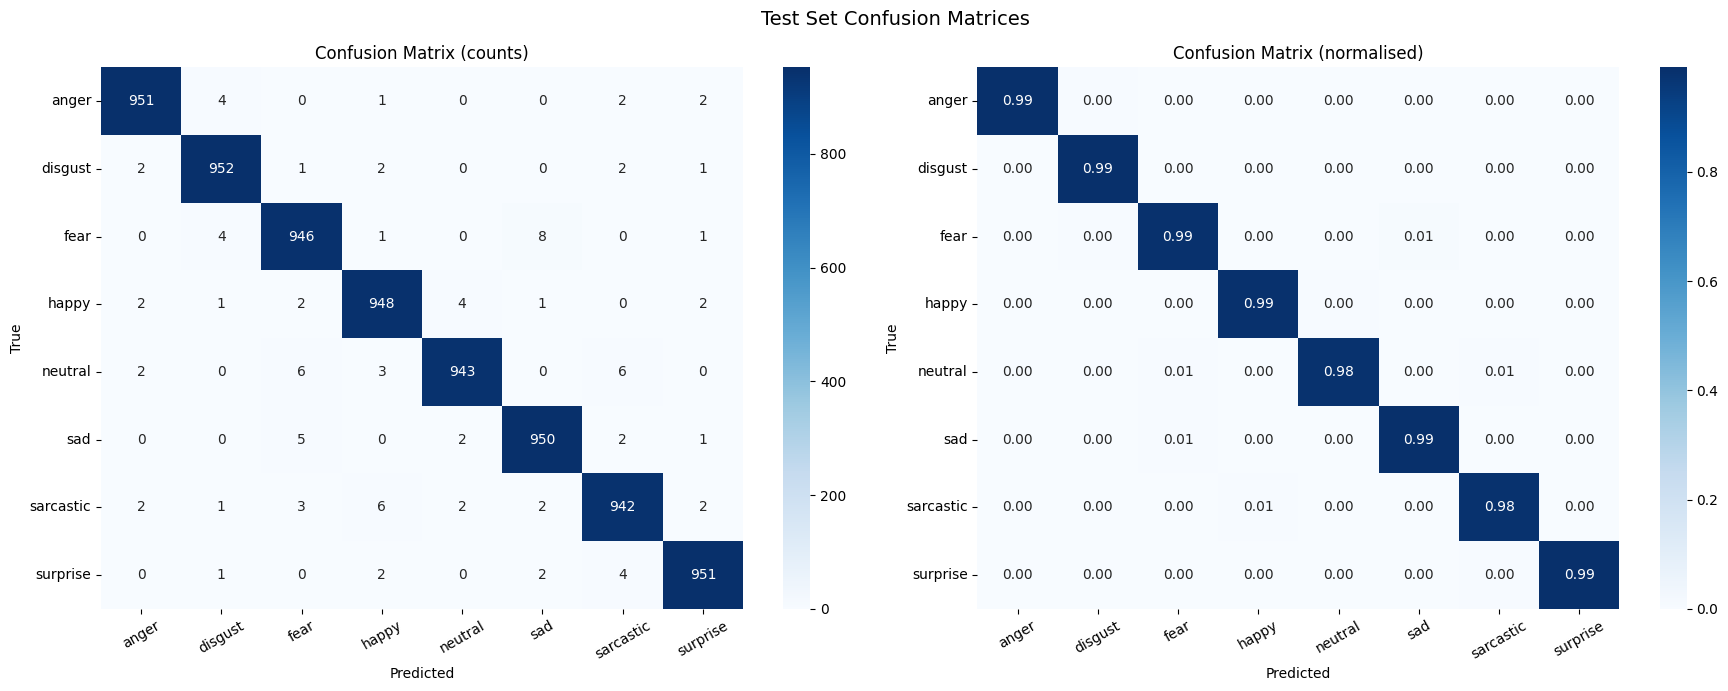

In [20]:
# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Test Set Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-class Accuracy Bar Chart

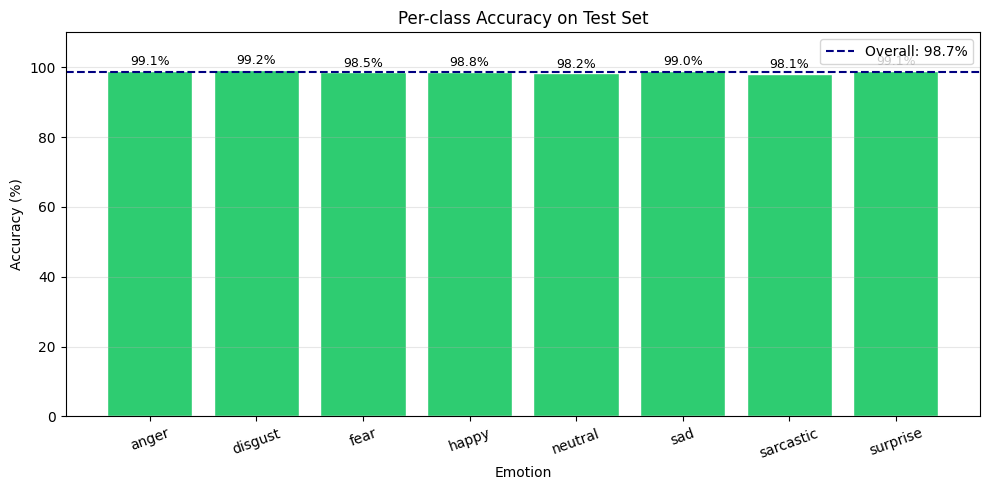

In [21]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if a >= 0.75 else '#e67e22' if a >= 0.50 else '#e74c3c'
          for a in per_class_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(EMOTIONS, per_class_acc * 100, color=colors, edgecolor='white')
plt.axhline(te_acc * 100, color='navy', linestyle='--',
            label=f'Overall: {te_acc*100:.1f}%')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.ylim(0, 110)
plt.xlabel('Emotion'); plt.ylabel('Accuracy (%)')
plt.title('Per-class Accuracy on Test Set')
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Inference on a Single File
Drop any `.wav` path below to get an emotion prediction.

In [22]:
def predict(filepath):
    """Predict emotion for a single .wav file."""
    mel    = extract_mel(filepath)
    mel_sc = scaler.transform(mel.reshape(1, -1)).reshape(1, N_MELS, -1)
    tensor = torch.FloatTensor(mel_sc[:, np.newaxis, :, :]).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx = probs.argmax()
    print(f'Predicted: {EMOTIONS[pred_idx].upper()}  ({probs[pred_idx]*100:.1f}%)')
    print('All probabilities:')
    for e, p in sorted(zip(EMOTIONS, probs), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {e:<12s} {bar:<30s} {p*100:5.1f}%')
    return EMOTIONS[pred_idx]


# ── Example usage ──
predict(r"C:\Users\Student\Downloads\meh.wav")
print('predict() function ready. Call predict(<path_to_wav>) to test.')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Student\\Downloads\\meh.wav'